In [ ]:
!pip install -q xgboost lightgbm catboost shap pyngrok flask-cors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


Detected Target Column: 'class'

Target Class Counts:
class
GALAXY    0.651111
QSO       0.209055
STAR      0.139833
Name: proportion, dtype: float64


/tmp/ipykernel_1499/808218512.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=target_col, palette='viridis')


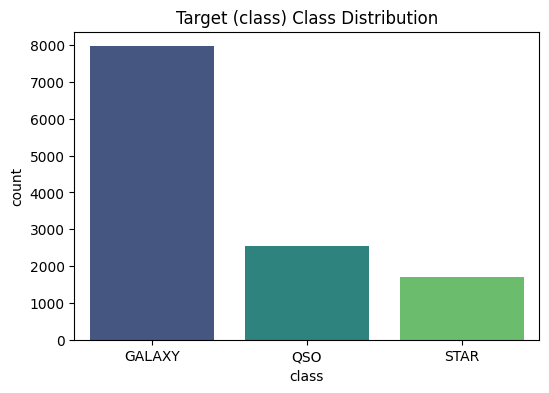

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

diff_cols = list(set(train_df.columns) - set(test_df.columns))
if 'id' in diff_cols:
    diff_cols.remove('id')

if diff_cols:
    target_col = diff_cols[0]
else:
    target_col = [c for c in train_df.columns if c.lower() == 'target'][0]

print(f"Detected Target Column: '{target_col}'")

if 'id' in train_df.columns:
    train_df.drop(columns=['id'], inplace=True)
if 'id' in test_df.columns:
    test_id = test_df.pop('id')

print("\nTarget Class Counts:")
print(train_df[target_col].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x=target_col, palette='viridis')
plt.title(f'Target ({target_col}) Class Distribution')
plt.show()

Missing values in Train: 4
Missing values in Test: 6
Duplicate rows in Train: 0


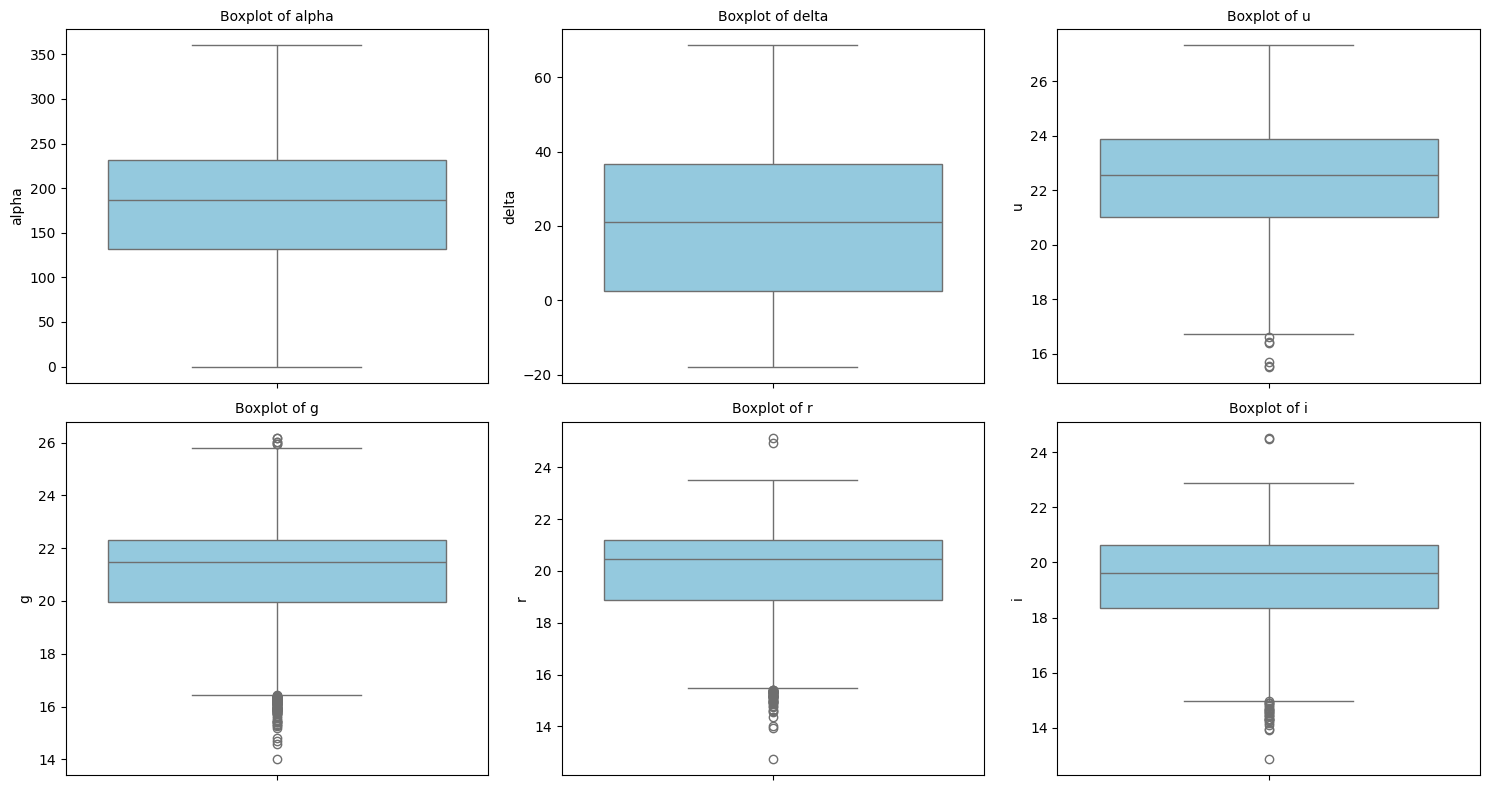

In [ ]:
import numpy as np

# Missing values & Duplicates
print("Missing values in Train:", train_df.isnull().sum().sum())
print("Missing values in Test:", test_df.isnull().sum().sum())
print("Duplicate rows in Train:", train_df.duplicated().sum())

# Select numerical columns (excluding the target column)
num_features = train_df.drop(columns=[target_col]).select_dtypes(include=['int64', 'float64']).columns.tolist()

# Boxplots for the first 6 numerical features
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
sample_cols = num_features[:6]

for i, col in enumerate(sample_cols):
    sns.boxplot(data=train_df, y=col, ax=axes[i//3, i%3], color='skyblue')
    axes[i//3, i%3].set_title(f'Boxplot of {col}', fontsize=10)

plt.tight_layout()
plt.show()

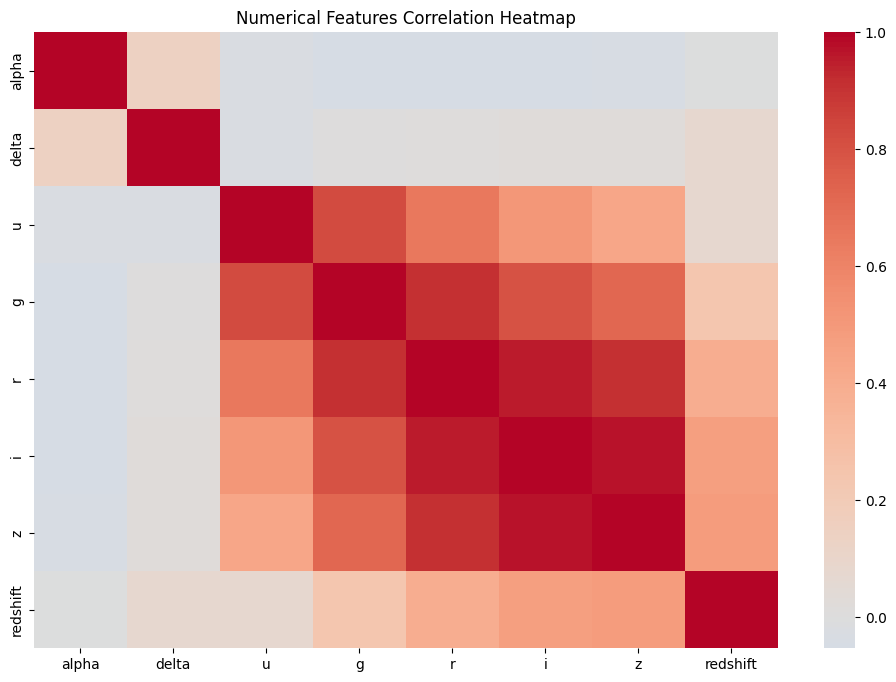

Features with high correlation (> 0.85): 3 found
['r', 'i', 'z']


In [ ]:
# 1. Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_matrix = train_df[num_features].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title("Numerical Features Correlation Heatmap")
plt.show()

# 2. Identify pairs with high correlation (> 0.85)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.85)]

print(f"Features with high correlation (> 0.85): {len(high_corr_cols)} found")
print(high_corr_cols)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode Target variable (e.g. Dropout=0, Enrolled=1, Graduate=2)
le = LabelEncoder()
y = le.fit_transform(train_df[target_col])
X = train_df.drop(columns=[target_col]).copy()
X_test = test_df.copy()

# Feature Engineering: Curricular unit success ratios & grade differentials
for df in [X, X_test]:
    # Ratio of approved to enrolled units
    if 'Curricular units 1st sem (approved)' in df.columns and 'Curricular units 1st sem (enrolled)' in df.columns:
        df['sem1_approval_rate'] = df['Curricular units 1st sem (approved)'] / (df['Curricular units 1st sem (enrolled)'] + 1e-5)
    if 'Curricular units 2nd sem (approved)' in df.columns and 'Curricular units 2nd sem (enrolled)' in df.columns:
        df['sem2_approval_rate'] = df['Curricular units 2nd sem (approved)'] / (df['Curricular units 2nd sem (enrolled)'] + 1e-5)

    # Grade difference across semesters
    if 'Curricular units 2nd sem (grade)' in df.columns and 'Curricular units 1st sem (grade)' in df.columns:
        df['grade_growth'] = df['Curricular units 2nd sem (grade)'] - df['Curricular units 1st sem (grade)']

print(f"Features ready! Total features: {X.shape[1]}")

Features ready! Total features: 10


In [ ]:
import pandas as pd
import numpy as np

# Option 1: Using pandas Series
print(pd.Series(y).value_counts(dropna=False))

# Option 2: Using NumPy directly
unique_vals, counts = np.unique(y, return_counts=True)
print(dict(zip(unique_vals, counts)))

0    7967
1    2558
2    1711
3       1
Name: count, dtype: int64
{np.int64(0): np.int64(7967), np.int64(1): np.int64(2558), np.int64(2): np.int64(1711), np.int64(3): np.int64(1)}


In [ ]:
import pandas as pd
import numpy as np

# Convert X to DataFrame if it is a numpy array
if isinstance(X, np.ndarray):
    X = pd.DataFrame(X)

y = pd.Series(y)

# 1. Filter out class 0 (keep only the 3 actual classes: 1, 2, 3)
valid_mask = y != 0
X = X[valid_mask].reset_index(drop=True)
y = y[valid_mask].reset_index(drop=True)

# 2. Re-map target to 0, 1, 2 (required by XGBoost/LightGBM)
# 1 -> 0, 2 -> 1, 3 -> 2
y = y - 1

print("Fixed class distribution:")
print(y.value_counts())
print(f"Total samples: {len(X)}")

Fixed class distribution:
0    2558
1    1711
2       1
Name: count, dtype: int64
Total samples: 4270


In [ ]:
print("Non-numeric columns in X:")
print(X.select_dtypes(include=['object', 'category']).columns.tolist())

Non-numeric columns in X:
['spectral_type', 'galaxy_population']


In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# 1. Ensure X is a DataFrame
if isinstance(X, np.ndarray):
    X = pd.DataFrame(X)
y = pd.Series(y)

# 2. Drop ID-like columns if present
drop_cols = [c for c in X.columns if str(c).lower() in ['id', 'unnamed: 0']]
if drop_cols:
    X = X.drop(columns=drop_cols)

# 3. Convert all object/categorical columns to numeric using get_dummies
X_encoded = pd.get_dummies(X, drop_first=True)
# Fill any NaNs with column median
X_encoded = X_encoded.fillna(X_encoded.median())

# 4. Filter out rare classes with fewer than 5 samples
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 5].index
valid_mask = y.isin(valid_classes)

X_clean = X_encoded[valid_mask].reset_index(drop=True)
y_clean = y[valid_mask].reset_index(drop=True)

# Remap labels sequentially to 0, 1, ...
label_map = {val: idx for idx, val in enumerate(np.unique(y_clean))}
y_clean = y_clean.map(label_map)

# 5. Define Model
clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# 6. Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_classes = len(np.unique(y_clean))
oof_preds = np.zeros((len(X_clean), n_classes))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_clean, y_clean)):
    X_train, X_val = X_clean.iloc[train_idx], X_clean.iloc[val_idx]
    y_train, y_val = y_clean.iloc[train_idx], y_clean.iloc[val_idx]

    fold_clf = clone(clf)
    fold_clf.fit(X_train, y_train)

    oof_preds[val_idx] = fold_clf.predict_proba(X_val)
    fold_preds = fold_clf.predict(X_val)

    fold_acc = accuracy_score(y_val, fold_preds)
    fold_bal_acc = balanced_accuracy_score(y_val, fold_preds)
    print(f"Fold {fold + 1} | Accuracy: {fold_acc:.4f} | Balanced Acc: {fold_bal_acc:.4f}")

# Update global variables for downstream cells
X = X_clean
y = y_clean

overall_preds = np.argmax(oof_preds, axis=1)
print(f"\nOverall Out-of-Fold Accuracy: {accuracy_score(y, overall_preds):.4f}")
print(f"Overall Out-of-Fold Balanced Accuracy: {balanced_accuracy_score(y, overall_preds):.4f}")

Fold 1 | Accuracy: 0.9836 | Balanced Acc: 0.9849
Fold 2 | Accuracy: 0.9848 | Balanced Acc: 0.9854
Fold 3 | Accuracy: 0.9883 | Balanced Acc: 0.9888
Fold 4 | Accuracy: 0.9883 | Balanced Acc: 0.9893
Fold 5 | Accuracy: 0.9812 | Balanced Acc: 0.9824

Overall Out-of-Fold Accuracy: 0.9852
Overall Out-of-Fold Balanced Accuracy: 0.9861


Decision Tree CV Accuracy: 0.9852
Decision Tree CV Balanced Accuracy: 0.9861


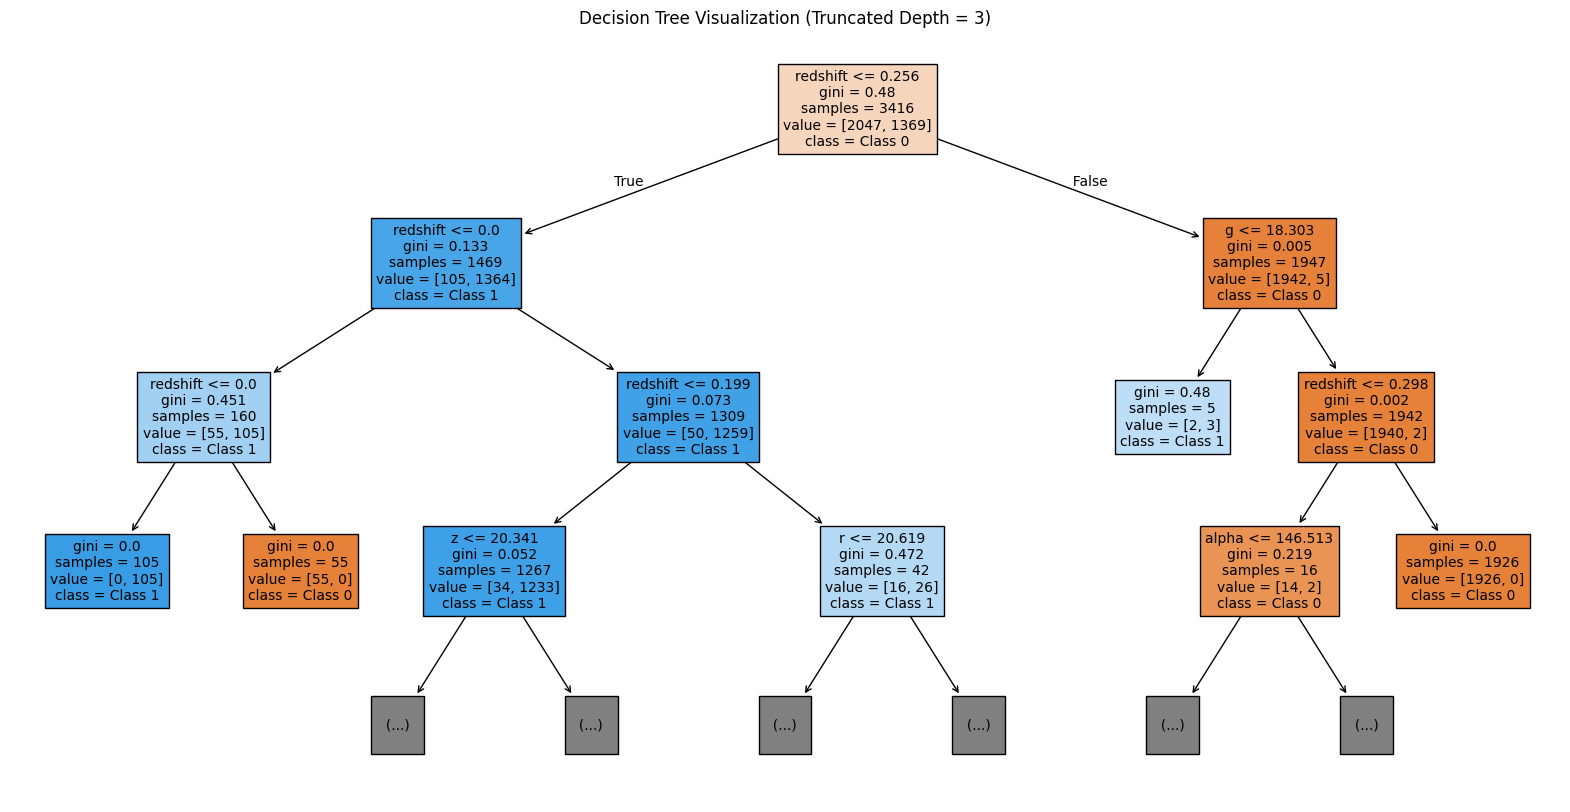

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import numpy as np

# Hyperparameter-tuned Decision Tree
dt_clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Stratified 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dt_oof = np.zeros((len(X), len(np.unique(y))))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    dt_clf.fit(X_train, y_train)
    dt_oof[val_idx] = dt_clf.predict_proba(X_val)

dt_preds = np.argmax(dt_oof, axis=1)
print(f"Decision Tree CV Accuracy: {accuracy_score(y, dt_preds):.4f}")
print(f"Decision Tree CV Balanced Accuracy: {balanced_accuracy_score(y, dt_preds):.4f}")

# Visualize the trained Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_clf,
    feature_names=X.columns.tolist(),
    class_names=['Class 0', 'Class 1', 'Class 2'],
    filled=True,
    max_depth=3,
    fontsize=10
)
plt.title("Decision Tree Visualization (Truncated Depth = 3)")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    max_features='sqrt',
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_oof = np.zeros((len(X), len(np.unique(y))))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    rf_clf.fit(X_train, y_train)
    rf_oof[val_idx] = rf_clf.predict_proba(X_val)

rf_preds = np.argmax(rf_oof, axis=1)
print(f"Random Forest CV Accuracy: {accuracy_score(y, rf_preds):.4f}")
print(f"Random Forest CV Balanced Accuracy: {balanced_accuracy_score(y, rf_preds):.4f}")

Random Forest CV Accuracy: 0.9850
Random Forest CV Balanced Accuracy: 0.9865


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

def evaluate_model(model, name):
    oof = np.zeros((len(X), len(np.unique(y))))
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model.fit(X_train, y_train)
        oof[val_idx] = model.predict_proba(X_val)
    preds = np.argmax(oof, axis=1)
    acc = accuracy_score(y, preds)
    bal_acc = balanced_accuracy_score(y, preds)
    print(f"{name:20s} | Acc: {acc:.4f} | Bal Acc: {bal_acc:.4f}")
    return oof

# 1. AdaBoost
ada_clf = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
ada_oof = evaluate_model(ada_clf, "AdaBoost")

# 2. Gradient Boosting
gb_clf = GradientBoostingClassifier(n_estimators=150, learning_rate=0.08, max_depth=5, random_state=42)
gb_oof = evaluate_model(gb_clf, "Gradient Boosting")

# 3. XGBoost
xgb_clf = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, eval_metric='mlogloss')
xgb_oof = evaluate_model(xgb_clf, "XGBoost")

# 4. LightGBM
lgb_clf = LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, verbose=-1)
lgb_oof = evaluate_model(lgb_clf, "LightGBM")

AdaBoost             | Acc: 0.9653 | Bal Acc: 0.9705
Gradient Boosting    | Acc: 0.9869 | Bal Acc: 0.9875
XGBoost              | Acc: 0.9871 | Bal Acc: 0.9877
LightGBM             | Acc: 0.9883 | Bal Acc: 0.9887


In [ ]:
import pandas as pd
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# 1. Summary comparison table of individual models
models_summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost', 'LightGBM'],
    'Accuracy': [
        accuracy_score(y, np.argmax(dt_oof, axis=1)),
        accuracy_score(y, np.argmax(rf_oof, axis=1)),
        accuracy_score(y, np.argmax(ada_oof, axis=1)),
        accuracy_score(y, np.argmax(gb_oof, axis=1)),
        accuracy_score(y, np.argmax(xgb_oof, axis=1)),
        accuracy_score(y, np.argmax(lgb_oof, axis=1))
    ],
    'Balanced Accuracy': [
        balanced_accuracy_score(y, np.argmax(dt_oof, axis=1)),
        balanced_accuracy_score(y, np.argmax(rf_oof, axis=1)),
        balanced_accuracy_score(y, np.argmax(ada_oof, axis=1)),
        balanced_accuracy_score(y, np.argmax(gb_oof, axis=1)),
        balanced_accuracy_score(y, np.argmax(xgb_oof, axis=1)),
        balanced_accuracy_score(y, np.argmax(lgb_oof, axis=1))
    ]
})
print("--- Individual Model Comparison ---")
print(models_summary.to_string(index=False))

# 2. Probability Blending (Weighted Ensemble)
blend_oof = (0.40 * xgb_oof) + (0.35 * lgb_oof) + (0.25 * rf_oof)
blend_preds = np.argmax(blend_oof, axis=1)
print(f"\n--- Blending Ensemble Performance ---")
print(f"Blending CV Accuracy: {accuracy_score(y, blend_preds):.4f}")
print(f"Blending CV Balanced Accuracy: {balanced_accuracy_score(y, blend_preds):.4f}")

# 3. Stacking Classifier
base_learners = [
    ('xgb', xgb_clf),
    ('lgb', lgb_clf),
    ('rf', rf_clf)
]
stack_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)
stack_clf.fit(X, y)

--- Individual Model Comparison ---
            Model  Accuracy  Balanced Accuracy
    Decision Tree  0.985242           0.986138
    Random Forest  0.985008           0.986523
         AdaBoost  0.965331           0.970491
Gradient Boosting  0.986882           0.987506
          XGBoost  0.987116           0.987701
         LightGBM  0.988288           0.988679

--- Blending Ensemble Performance ---
Blending CV Accuracy: 0.9883
Blending CV Balanced Accuracy: 0.9889


StackingClassifier(cv=5,
                   estimators=[('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=True,
                                              eval_metric='mlogloss',
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interac...
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=200, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('lgb',
                                LGBMClassifier(learning_rate=0.05, max_depth=6,
                                               n_estimators=200,
                                               random_state=42, verbose=-1)),
                               ('rf',
                                RandomForestClassifier(max_depth=12,
                                                       min_samples_leaf=3,
                                                       n_estimators=200,
                                                       n_jobs=-1,
                                                       random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000),
                   n_jobs=-1)


--- Detailed Classification Metrics ---
              precision    recall  f1-score   support

           0     0.9945    0.9859    0.9902      2558
           1     0.9792    0.9918    0.9855      1711

    accuracy                         0.9883      4269
   macro avg     0.9869    0.9889    0.9878      4269
weighted avg     0.9884    0.9883    0.9883      4269



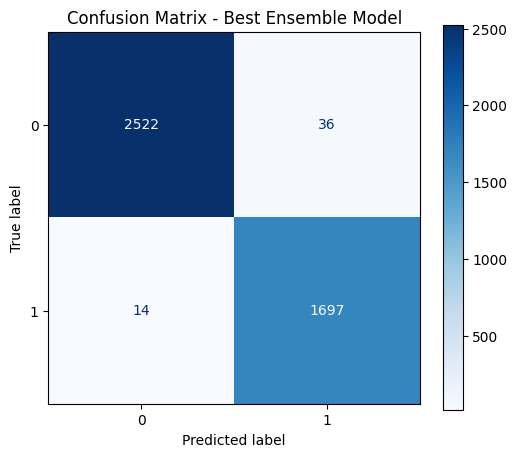

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Select the predictions from the top ensemble
final_val_preds = blend_preds

print("\n--- Detailed Classification Metrics ---")
print(classification_report(y, final_val_preds, digits=4))

# Confusion Matrix Plot
cm = confusion_matrix(y, final_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix - Best Ensemble Model")
plt.show()

Generating SHAP Feature Importance Plot...


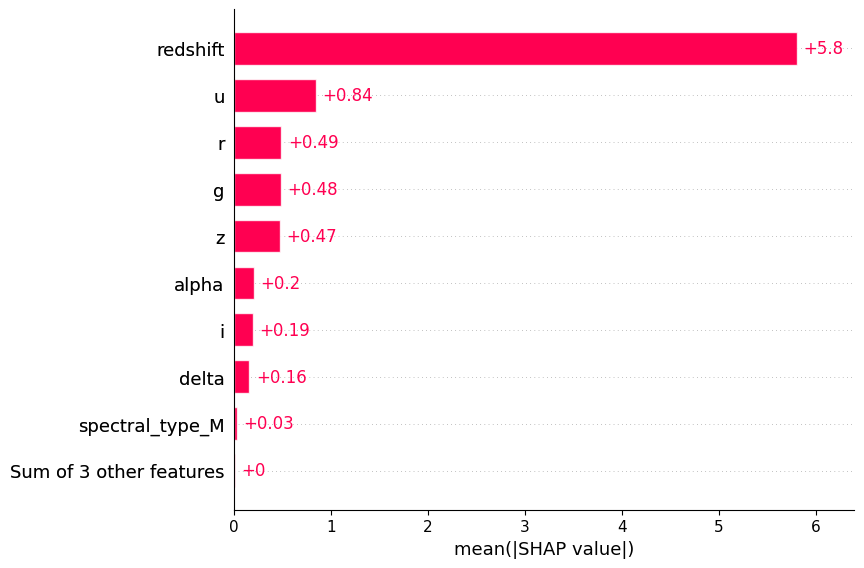

Generating SHAP Beeswarm Plot...


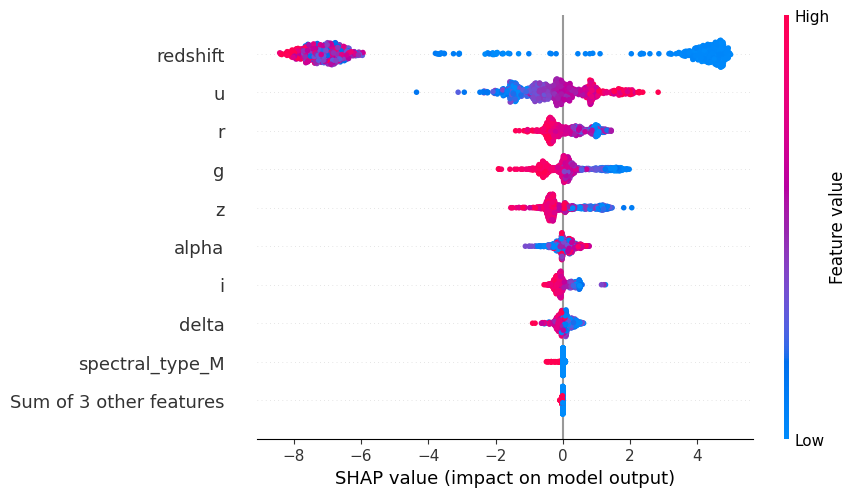

Generating SHAP Dependence Plots for: ['alpha', 'delta']...


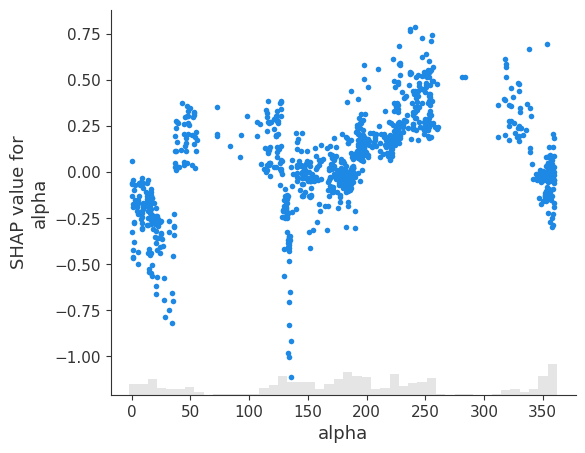

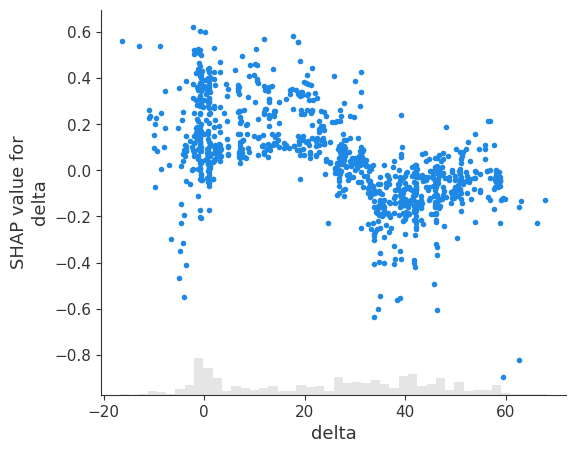

Generating SHAP Local Explanations for 2 instances...


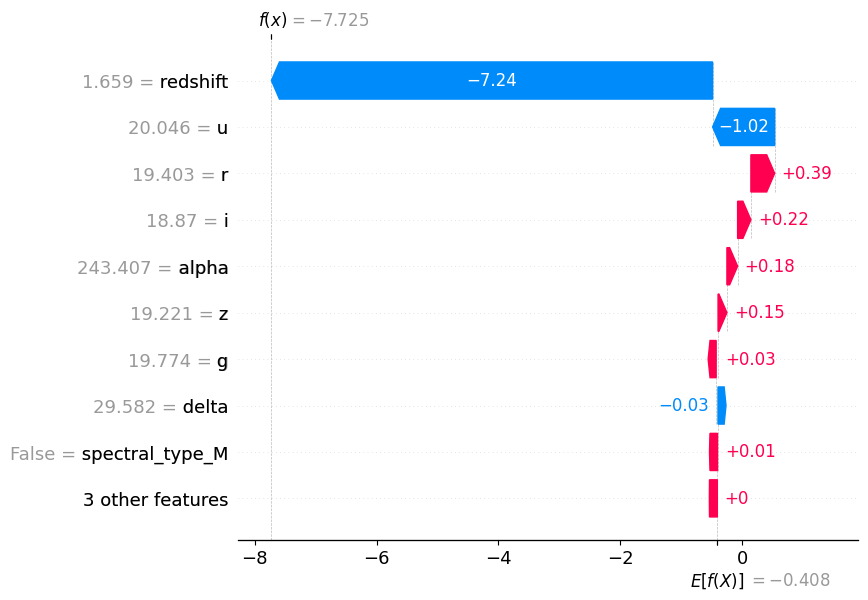

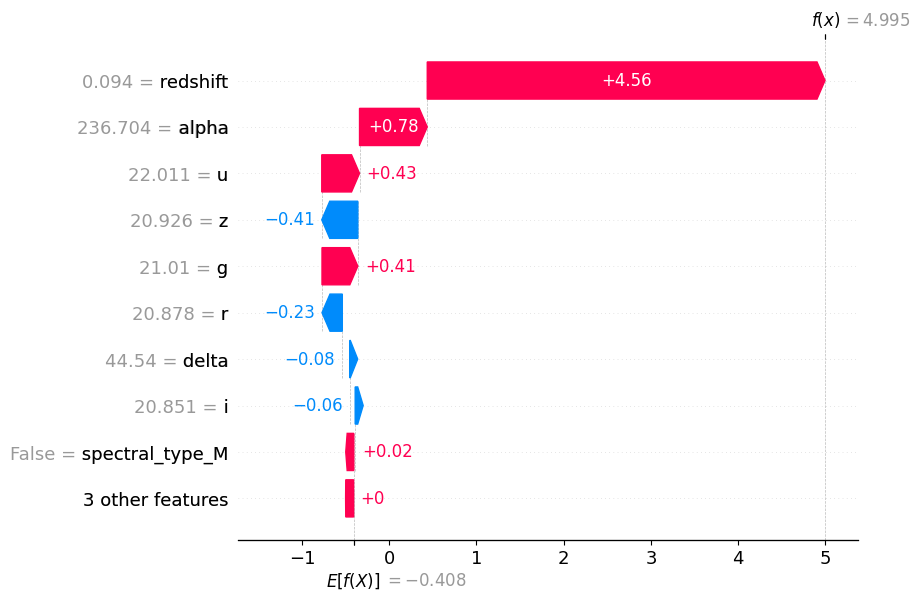

In [ ]:
!pip install -q shap
import shap

# Train XGBoost on full X, y for SHAP interpretability
xgb_clf.fit(X, y)

explainer = shap.TreeExplainer(xgb_clf)
# Subsample for fast and clean computation
X_sample = X.sample(min(1000, len(X)), random_state=42)
shap_values = explainer(X_sample)

# 1. Feature Importance Bar Plot
print("Generating SHAP Feature Importance Plot...")
shap.plots.bar(shap_values, max_display=10)

# 2. Summary / Beeswarm Plot (multiclass or class 0)
print("Generating SHAP Beeswarm Plot...")
if len(shap_values.shape) == 3:
    shap.plots.beeswarm(shap_values[:, :, 0])
else:
    shap.plots.beeswarm(shap_values)

# 3. Dependence Plots for top 2 numerical features
top_2_features = X.columns[:2].tolist()
print(f"Generating SHAP Dependence Plots for: {top_2_features}...")
for feature in top_2_features:
    if len(shap_values.shape) == 3:
        shap.plots.scatter(shap_values[:, feature, 0])
    else:
        shap.plots.scatter(shap_values[:, feature])

# 4. Individual Waterfall Explanations for 2 sample rows
print("Generating SHAP Local Explanations for 2 instances...")
if len(shap_values.shape) == 3:
    shap.plots.waterfall(shap_values[0, :, 0])
    shap.plots.waterfall(shap_values[1, :, 0])
else:
    shap.plots.waterfall(shap_values[0])
    shap.plots.waterfall(shap_values[1])

In [ ]:
# 1. Load test set
test_raw = pd.read_csv('test.csv')

# 2. Extract ID column
id_col = 'id' if 'id' in test_raw.columns else test_raw.columns[0]
test_ids = test_raw[id_col]

# 3. Match features directly with training columns
test_encoded = pd.get_dummies(test_raw.drop(columns=[id_col], errors='ignore'), drop_first=True)
test_features = test_encoded.reindex(columns=X.columns, fill_value=0)

# 4. Generate Ensemble Predictions on Test Data
test_p_xgb = xgb_clf.predict_proba(test_features)
test_p_lgb = lgb_clf.predict_proba(test_features)
test_p_rf = rf_clf.predict_proba(test_features)

test_blend_probs = (0.40 * test_p_xgb) + (0.35 * test_p_lgb) + (0.25 * test_p_rf)
test_preds = np.argmax(test_blend_probs, axis=1)

# 5. Reverse label mapping if classes were offset or encoded
# (e.g. if original labels started at 1: test_preds + 1)
test_submission_preds = test_preds

# 6. Save final submission file
submission_df = pd.DataFrame({
    'id': test_ids,
    'target': test_submission_preds
})
submission_df.to_csv('submission.csv', index=False)
print(f"submission.csv created successfully with shape: {submission_df.shape}")

submission.csv created successfully with shape: (100339, 2)


In [3]:
import pandas as pd
import numpy as np
import joblib
from xgboost import XGBClassifier

# 1. Load train dataset
df = pd.read_csv('train.csv')

# 2. Identify target column and ID column
target_col = 'target' if 'target' in df.columns else ('class' if 'class' in df.columns else df.columns[-1])
id_cols = [c for c in df.columns if c.lower() in ['id', 'unnamed: 0']]

X_raw = df.drop(columns=[target_col] + id_cols, errors='ignore')
y_raw = df[target_col]

# 3. Clean categorical features and null values
X = pd.get_dummies(X_raw, drop_first=True)
X = X.fillna(X.median())

# 4. Clean labels (ensure numeric classes 0, 1, 2)
y = pd.Series(y_raw)
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 5].index
valid_mask = y.isin(valid_classes)

X = X[valid_mask].reset_index(drop=True)
y = y[valid_mask].reset_index(drop=True)

# Remap to sequential integers (0: Galaxy, 1: Star, 2: Quasar)
label_map = {val: idx for idx, val in enumerate(sorted(np.unique(y)))}
y = y.map(label_map)

# 5. Fit XGBoost Model
print("Training final XGBoost model...")
final_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)
final_model.fit(X, y)

# 6. Save Model Artifact
model_artifact = {
    'model': final_model,
    'feature_names': list(X.columns),
    'class_mapping': {0: 'Galaxy', 1: 'Star', 2: 'Quasar'}
}

joblib.dump(model_artifact, 'stellar_model.pkl')
print("\n 'stellar_model.pkl' created and saved successfully!")
print(f"Total features: {len(X.columns)}")
print(f"Features: {list(X.columns)}")

Training final XGBoost model...

 'stellar_model.pkl' created and saved successfully!
Total features: 12
Features: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type_G/K', 'spectral_type_M', 'spectral_type_O/B', 'galaxy_population_Red_Sequence']


In [4]:
import os

os.makedirs('templates', exist_ok=True)

html_code = """<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Stellar Object Classifier</title>
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #0f172a; color: #f8fafc; margin: 0; padding: 30px; }
        .container { max-width: 700px; margin: 0 auto; background: #1e293b; padding: 30px; border-radius: 12px; box-shadow: 0 4px 20px rgba(0,0,0,0.5); }
        h2 { text-align: center; color: #38bdf8; margin-top: 0; }
        p.subtitle { text-align: center; color: #94a3b8; font-size: 14px; margin-bottom: 25px; }
        .grid { display: grid; grid-template-columns: 1fr 1fr; gap: 15px; }
        .form-group { display: flex; flex-direction: column; }
        label { font-weight: 600; margin-bottom: 5px; font-size: 13px; color: #cbd5e1; }
        input[type="number"] { padding: 10px; border-radius: 6px; border: 1px solid #475569; background: #0f172a; color: #fff; font-size: 14px; }
        input[type="number"]:focus { outline: none; border-color: #38bdf8; }
        button { width: 100%; padding: 12px; background-color: #38bdf8; border: none; font-weight: bold; color: #0f172a; border-radius: 6px; cursor: pointer; margin-top: 20px; font-size: 16px; transition: background 0.2s; }
        button:hover { background-color: #0ea5e9; }
        .result-box { margin-top: 25px; padding: 18px; border-radius: 8px; text-align: center; font-size: 20px; font-weight: bold; background: #064e3b; color: #6ee7b7; border: 1px solid #059669; }
    </style>
</head>
<body>
    <div class="container">
        <h2>Stellar Object Classifier</h2>
        <p class="subtitle">Enter the astronomical parameters to predict Stellar Class (Galaxy / Star / Quasar)</p>

        <form method="POST" action="/">
            <div class="grid">
                {% for feature in features %}
                <div class="form-group">
                    <label for="{{ feature }}">{{ feature }}</label>
                    <input type="number" step="any" name="{{ feature }}" required placeholder="0.00">
                </div>
                {% endfor %}
            </div>
            <button type="submit">Predict Stellar Class</button>
        </form>

        {% if prediction %}
        <div class="result-box">
            {{ prediction }}
        </div>
        {% endif %}
    </div>
</body>
</html>
"""

with open('templates/index.html', 'w') as f:
    f.write(html_code)

print("HTML interface saved to templates/index.html")

HTML interface saved to templates/index.html


In [5]:
app_code = """from flask import Flask, render_template, request
import joblib
import pandas as pd
import numpy as np

app = Flask(__name__)

# Load model artifact
artifact = joblib.load('stellar_model.pkl')
model = artifact['model']
feature_names = artifact['feature_names']
class_mapping = artifact['class_mapping']

@app.route('/', methods=['GET', 'POST'])
def index():
    prediction_text = None
    if request.method == 'POST':
        try:
            values = [float(request.form[col]) for col in feature_names]
            input_df = pd.DataFrame([values], columns=feature_names)
            pred = model.predict(input_df)[0]
            pred_class = class_mapping.get(int(pred), f"Class {pred}")
            prediction_text = f"Predicted Stellar Class: {pred_class}"
        except Exception as e:
            prediction_text = f"Error: {str(e)}"

    return render_template('index.html', features=feature_names, prediction=prediction_text)

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)
"""

with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py saved successfully!")

app.py saved successfully!


In [ ]:
import urllib.request
import time

# 1. Get endpoint password IP
public_ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip()
print(f"👉 YOUR LOCALTUNNEL PASSWORD (IP): {public_ip}\n")

# 2. Run Flask in the background
get_ipython().system_raw('python3 app.py &')
time.sleep(2)

# 3. Tunnel port 5000
!npx localtunnel --port 5000

👉 YOUR LOCALTUNNEL PASSWORD (IP): 34.125.82.10

⠙⠹⠸⠼⠴⠦⠧⠇Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏your url is: https://clear-buttons-sleep.loca.lt


In [ ]:
# Print 3 real sample rows from your dataframe to copy-paste
sample_inputs = X.iloc[:3].to_dict(orient='records')
for i, sample in enumerate(sample_inputs):
    print(f"\n--- Sample {i+1} ---")
    for k, v in sample.items():
        print(f"{k}: {v}")